# Forest Cover Type

I just finished Andrew Ng's Machine Learning Specialization on Coursera and wanted to see how the techniques actually behave on a real, big-ish dataset instead of the toy ones in the assignments. This notebook runs end to end: load the data, look at it, then walk through the models the course covers — logistic regression (from scratch and with sklearn), a neural net (from scratch and with Keras), trees and a gradient-boosted ensemble — and finishes with PCA and K-means as a sanity check on what unsupervised methods see in the same features.

Dataset: UCI Covertype, 581k rows, 54 features, 7 forest cover types. The label is the dominant tree species in a 30x30m patch of US forest, predicted from cartographic and soil variables.

## 1. Setup and load

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data
import models
import plots

plots.apply_style()

X_train, y_train, X_val, y_val, X_test, y_test = data.load(seed=0)
print(f"train {X_train.shape}, val {X_val.shape}, test {X_test.shape}")
print(f"features: {X_train.shape[1]} (10 continuous, 4 wilderness, 40 soil)")

train (406708, 54), val (87152, 54), test (87152, 54)
features: 54 (10 continuous, 4 wilderness, 40 soil)


The continuous columns are standardised on the training split, then the same transform is applied to val/test. The 44 binary indicator columns are left alone.

## 2. A look at the data

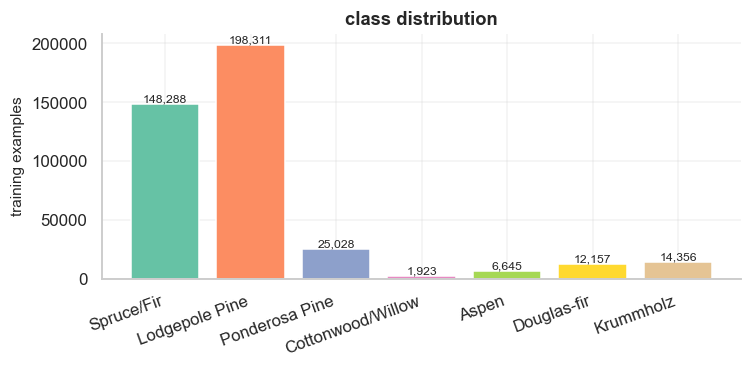

In [2]:
plots.class_balance_bar(y_train, data.CLASS_NAMES)
plt.tight_layout()
plt.show()

The two most common classes (Spruce/Fir and Lodgepole Pine) make up about 85% of the data. That's worth remembering when reading accuracy numbers — a model that predicts only those two would already get a misleadingly high score.

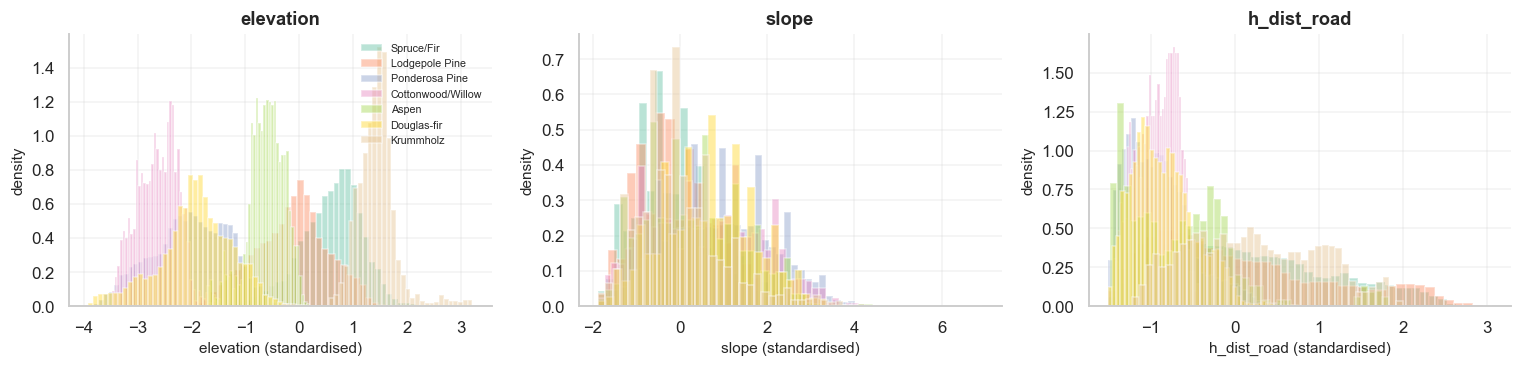

In [3]:
# distributions of a few continuous features, colored by class
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["elevation", "slope", "h_dist_road"]):
    j = data.CONTINUOUS.index(col)
    for c in range(7):
        ax.hist(X_train[y_train == c, j], bins=40, alpha=0.45,
                color=plots.PALETTE[c], label=data.CLASS_NAMES[c], density=True)
    ax.set_title(col)
    ax.set_xlabel(f"{col} (standardised)")
    ax.set_ylabel("density")
    if col == "elevation":
        ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

Elevation alone almost separates Krummholz from Cottonwood/Willow — the trees grow in different bands. That hints at why a tree-based model should do well here.

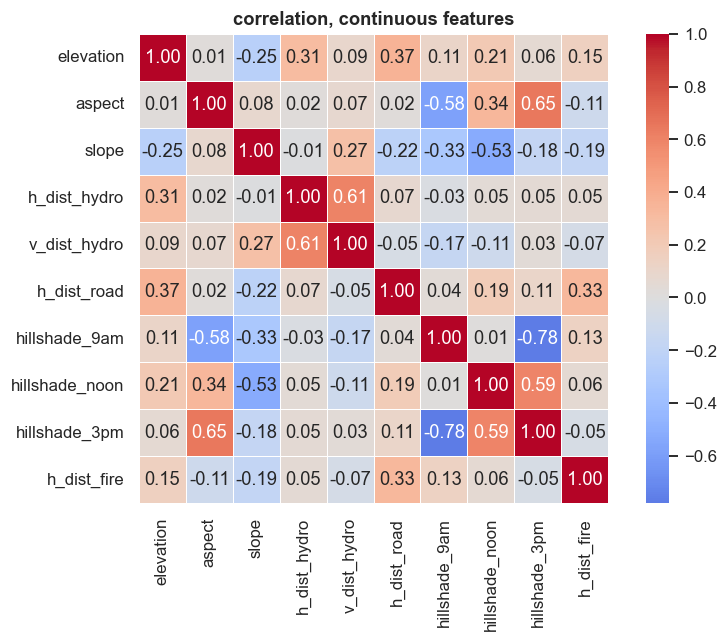

In [4]:
# correlations among continuous features
fig, ax = plt.subplots(figsize=(8, 6))
corr = pd.DataFrame(X_train[:, :10], columns=data.CONTINUOUS).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            cbar=True, square=True, linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("correlation, continuous features")
plt.tight_layout()
plt.show()

## 3. Logistic regression from scratch

Multiclass logistic regression — softmax output, mini-batch gradient descent with L2. I train on a 60k stratified subsample to keep iteration cheap; the sklearn version below uses the full training set.

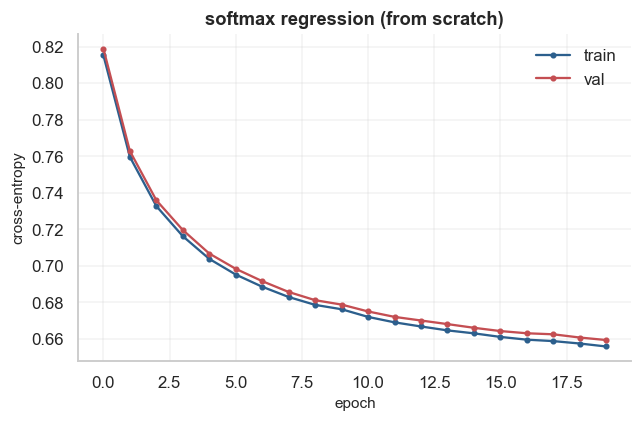

val accuracy: 0.718


In [5]:
rng = np.random.default_rng(0)
sub = rng.choice(len(X_train), 60_000, replace=False)
Xs, ys = X_train[sub], y_train[sub]

clf_scratch = models.SoftmaxRegression(
    n_classes=7, lr=0.2, l2=1e-4, epochs=20, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

plots.loss_curve(clf_scratch.history, "softmax regression (from scratch)")
plt.tight_layout()
plt.show()
print(f"val accuracy: {(clf_scratch.predict(X_val) == y_val).mean():.3f}")

## 4. Logistic regression with sklearn

In [6]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(
    solver="lbfgs", C=1.0, max_iter=200, n_jobs=-1
).fit(X_train, y_train)
print(f"val accuracy: {clf_sk.score(X_val, y_val):.3f}")

val accuracy: 0.725


The two should land in the same neighbourhood. They won't be identical: sklearn uses L-BFGS on the full data, my from-scratch one uses SGD on a subsample. The point is the math agrees.

## 5. Softmax neural net from scratch

One hidden layer, ReLU, He init, mini-batch SGD with L2. Same 60k subsample as before.

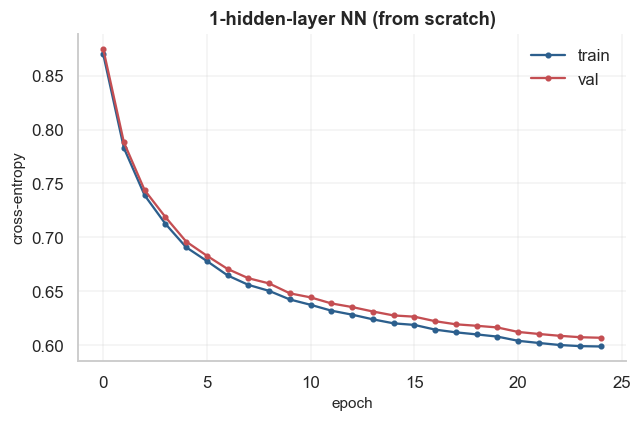

val accuracy: 0.742


In [7]:
nn_scratch = models.SoftmaxNN(
    n_classes=7, hidden=128, lr=0.05, l2=1e-4, epochs=25, batch=512, seed=0
).fit(Xs, ys, X_val, y_val)

plots.loss_curve(nn_scratch.history, "1-hidden-layer NN (from scratch)")
plt.tight_layout()
plt.show()
print(f"val accuracy: {(nn_scratch.predict(X_val) == y_val).mean():.3f}")

## 6. Same network in Keras

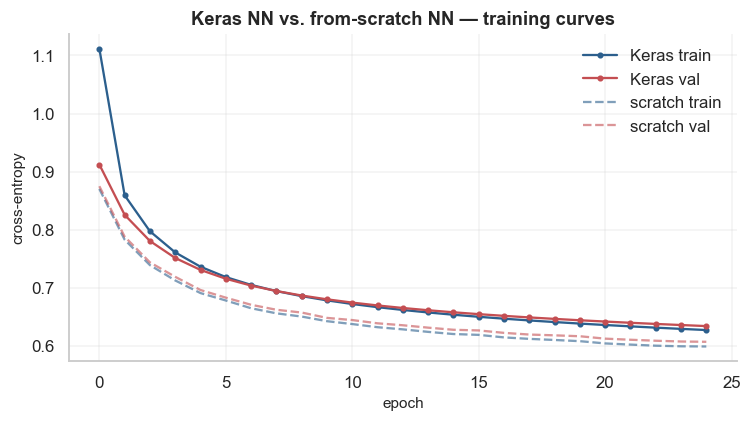

val accuracy: 0.745


In [8]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.random.set_seed(0)

nn_keras = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu",
        kernel_initializer="he_normal",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(7, activation="softmax",
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
])
nn_keras.compile(
    optimizer=tf.keras.optimizers.SGD(0.05),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
hist = nn_keras.fit(
    Xs, ys, validation_data=(X_val, y_val),
    epochs=25, batch_size=512, verbose=0,
)

# overlay both NN training curves on one panel
fig, ax = plt.subplots(figsize=(7, 4))
epochs = range(len(hist.history["loss"]))
ax.plot(epochs, hist.history["loss"], "-o", ms=3, color=plots.ACCENT,
        label="Keras train")
ax.plot(epochs, hist.history["val_loss"], "-o", ms=3, color=plots.WARN,
        label="Keras val")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["train_loss"] for h in nn_scratch.history],
        "--", color=plots.ACCENT, alpha=0.6, label="scratch train")
ax.plot([h["epoch"] for h in nn_scratch.history],
        [h["val_loss"] for h in nn_scratch.history],
        "--", color=plots.WARN, alpha=0.6, label="scratch val")
ax.set_xlabel("epoch")
ax.set_ylabel("cross-entropy")
ax.set_title("Keras NN vs. from-scratch NN — training curves")
ax.legend()
plt.tight_layout()
plt.show()
print(f"val accuracy: {hist.history['val_accuracy'][-1]:.3f}")

Keras matches the from-scratch version closely, which is reassuring — it means I didn't fudge the gradient. The two curves nearly overlap once training settles.

## 7. Trees and gradient boosting

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

dt = DecisionTreeClassifier(max_depth=20, random_state=0).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=0).fit(X_train, y_train)
hgb = HistGradientBoostingClassifier(max_iter=200, random_state=0).fit(X_train, y_train)

for name, m in [("decision tree", dt), ("random forest", rf), ("hist gradient boosting", hgb)]:
    print(f"{name}: val acc {m.score(X_val, y_val):.3f}")

decision tree: val acc 0.905


random forest: val acc 0.952
hist gradient boosting: val acc 0.780


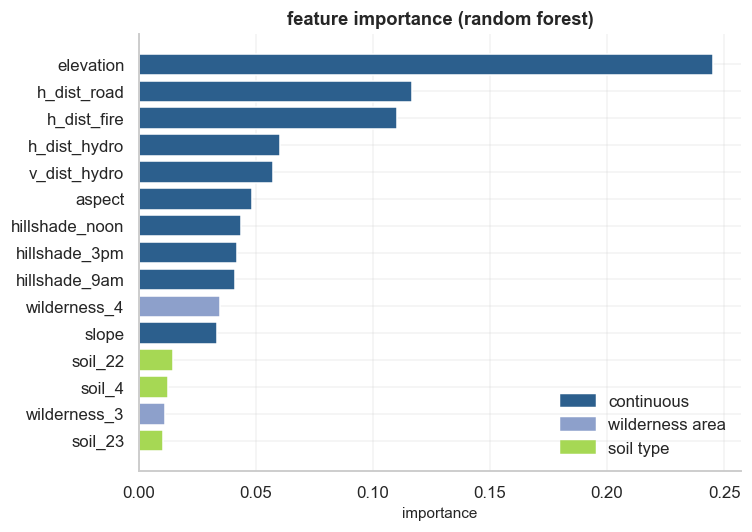

In [10]:
# top features according to the random forest, coloured by category
plots.feature_importance(
    np.array(data.CONTINUOUS + data.WILDERNESS + data.SOIL),
    rf.feature_importances_, top=15,
)
plt.tight_layout()
plt.show()

Elevation dominates, as expected from the EDA. Distance-to-roadways and the hillshade values pull weight too. Soil and wilderness indicators show up further down the list — useful, but each one alone is much weaker than the geographic continuous features.

## 8. Bias / variance and learning curves

Pick the two strongest models from above (random forest and the gradient-boosted trees) and see how their validation error moves with training-set size. If train and val accuracy are both flat and far apart, that's variance; if both are low and close, that's bias.

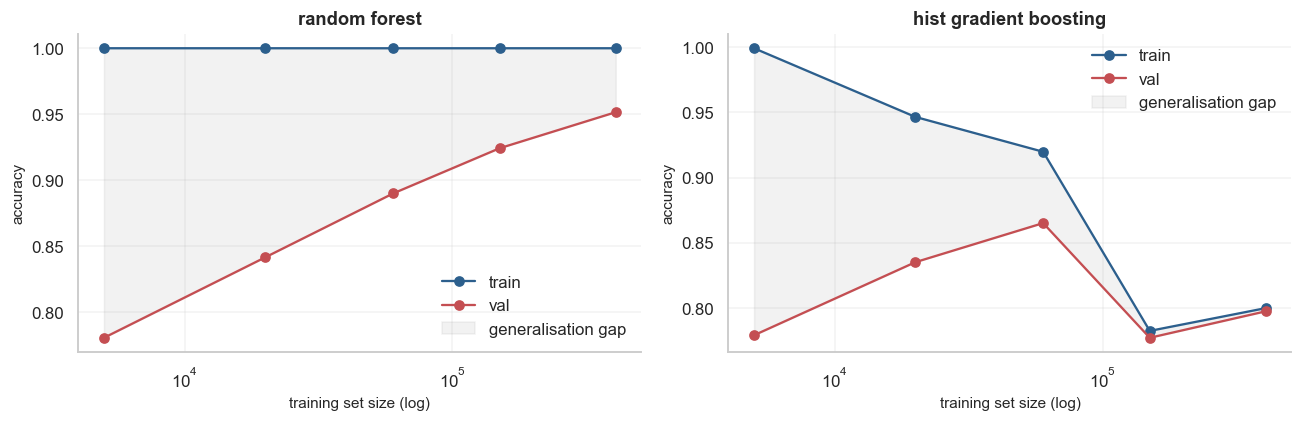

In [11]:
sizes = [5_000, 20_000, 60_000, 150_000, len(X_train)]
rf_train, rf_val = [], []
hgb_train, hgb_val = [], []

for n in sizes:
    idx = rng.choice(len(X_train), n, replace=False)
    Xn, yn = X_train[idx], y_train[idx]
    rf_n = RandomForestClassifier(n_estimators=80, n_jobs=-1, random_state=0).fit(Xn, yn)
    hgb_n = HistGradientBoostingClassifier(max_iter=150, random_state=0).fit(Xn, yn)
    rf_train.append(rf_n.score(Xn, yn))
    rf_val.append(rf_n.score(X_val, y_val))
    hgb_train.append(hgb_n.score(Xn, yn))
    hgb_val.append(hgb_n.score(X_val, y_val))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plots.learning_curve(sizes, rf_train, rf_val, "random forest", ax=axes[0])
plots.learning_curve(sizes, hgb_train, hgb_val, "hist gradient boosting", ax=axes[1])
plt.tight_layout()
plt.show()

Random forest sits at ~1.0 train accuracy across the range — classic high-variance behaviour. The gap between train and val closes as n grows but doesn't fully shut, so more data is still helping. HistGB's curves are tighter together, which lines up with the regularisation it does internally.

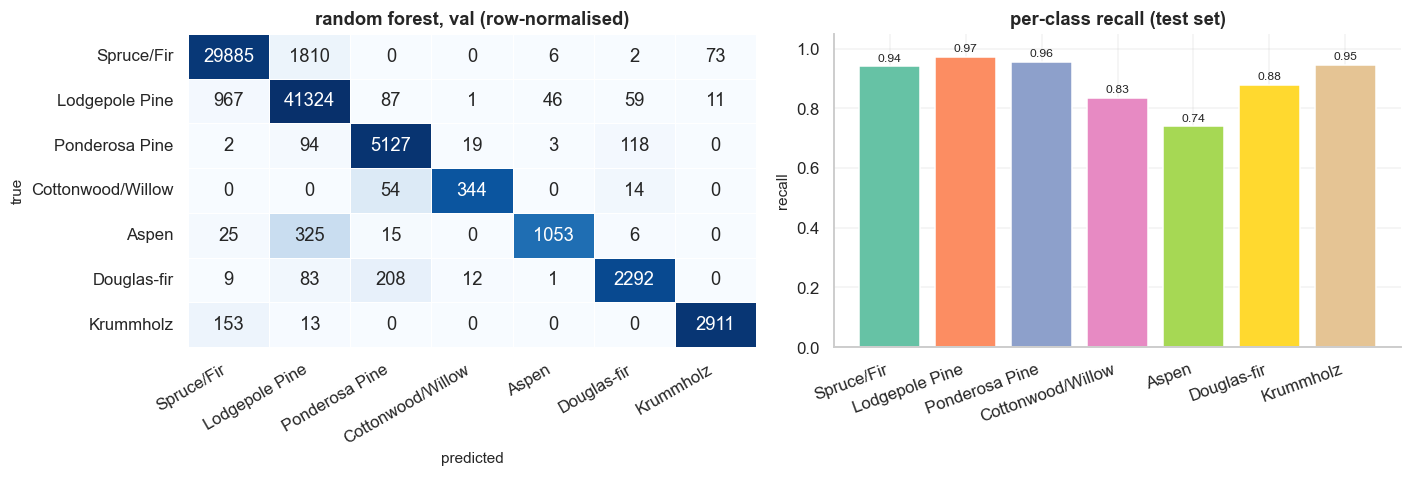

In [12]:
# error analysis: where does the random forest go wrong?
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plots.confusion(y_val, rf.predict(X_val), data.CLASS_NAMES,
                "random forest, val (row-normalised)", ax=axes[0])
plots.per_class_recall(y_val, rf.predict(X_val), data.CLASS_NAMES, ax=axes[1])
plt.tight_layout()
plt.show()

Most of the residual error is Spruce/Fir vs Lodgepole Pine. They cover overlapping elevation ranges and similar soils, so it's not surprising — the features genuinely don't separate them perfectly. The per-class recall plot shows the smaller classes (Cottonwood/Willow, Aspen) actually do quite well — the random forest doesn't get fooled by the imbalance the way the linear model does.

## 9. PCA

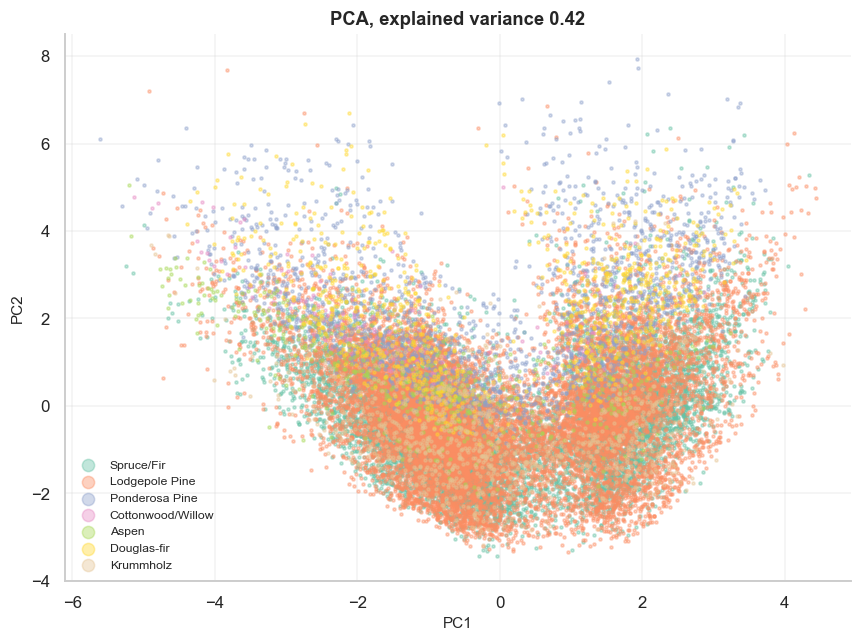

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
sub_idx = rng.choice(len(X_train), 30_000, replace=False)
X2 = pca.fit_transform(X_train[sub_idx])

plots.pca_scatter(X2, y_train[sub_idx], data.CLASS_NAMES,
                  f"PCA, explained variance {pca.explained_variance_ratio_.sum():.2f}")
plt.tight_layout()
plt.show()

Two PCs only catch about a quarter of the variance, which is why the classes look smeared together. That doesn't mean the data is unseparable — the supervised models above proved otherwise — just that linear projection to 2D throws away most of the signal here.

## 10. K-means

Fit k=7 on the feature space (matching the number of true classes) and see how cluster assignments line up with the labels. The expectation is *not* that they match — K-means is unsupervised and has no reason to recover the same partition.

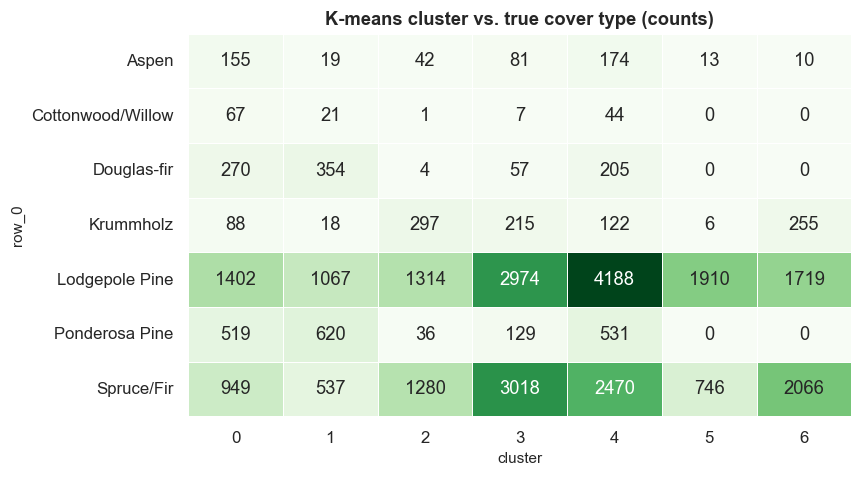

cluster,0,1,2,3,4,5,6
row_0,,,,,,,
Aspen,155,19,42,81,174,13,10
Cottonwood/Willow,67,21,1,7,44,0,0
Douglas-fir,270,354,4,57,205,0,0
Krummholz,88,18,297,215,122,6,255
Lodgepole Pine,1402,1067,1314,2974,4188,1910,1719
Ponderosa Pine,519,620,36,129,531,0,0
Spruce/Fir,949,537,1280,3018,2470,746,2066


In [14]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=7, n_init=10, random_state=0).fit(X_train[sub_idx])
ct = pd.crosstab(
    pd.Series(y_train[sub_idx]).map(dict(enumerate(data.CLASS_NAMES))),
    pd.Series(km.labels_, name="cluster"),
)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(ct, cmap="Greens", annot=True, fmt="d", cbar=False,
            linewidths=0.4, linecolor="white", ax=ax)
ax.set_title("K-means cluster vs. true cover type (counts)")
plt.tight_layout()
plt.show()
ct

Some clusters do correspond to a single class (the Krummholz cluster is fairly clean, since elevation isolates them), but most of the seven classes are split across several clusters. The takeaway is the one the lectures make: K-means finds compact groups in the feature space, and those groups are not necessarily the labels you care about.

## 11. Final comparison

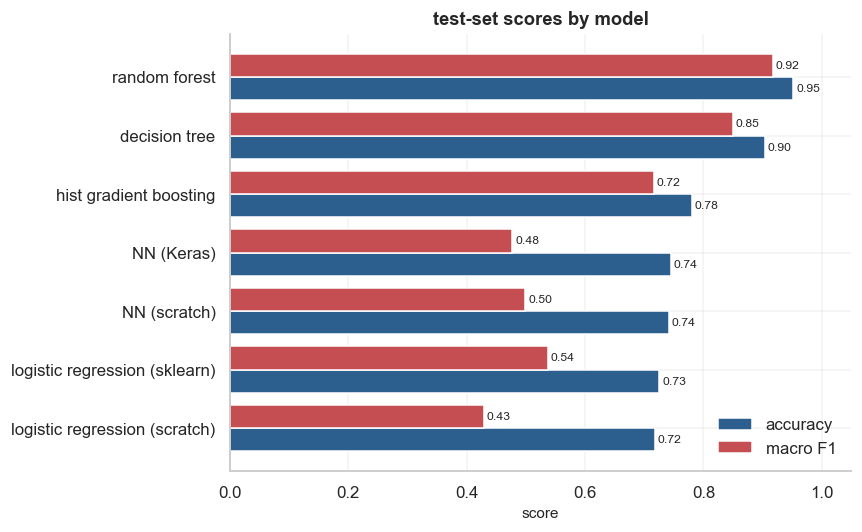

,model,accuracy,macro F1
0,random forest,0.952,0.917
1,decision tree,0.904,0.849
2,hist gradient boosting,0.780,0.716
3,NN (Keras),0.745,0.477
4,NN (scratch),0.741,0.499
5,logistic regression (sklearn),0.726,0.537
6,logistic regression (scratch),0.718,0.429


In [15]:
from sklearn.metrics import accuracy_score, f1_score

def score(name, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro F1": f1_score(y_test, y_pred, average="macro"),
    }

results = pd.DataFrame([
    score("logistic regression (scratch)", clf_scratch.predict(X_test)),
    score("logistic regression (sklearn)", clf_sk.predict(X_test)),
    score("NN (scratch)", nn_scratch.predict(X_test)),
    score("NN (Keras)", nn_keras.predict(X_test, verbose=0).argmax(axis=1)),
    score("decision tree", dt.predict(X_test)),
    score("random forest", rf.predict(X_test)),
    score("hist gradient boosting", hgb.predict(X_test)),
])

plots.model_comparison(results)
plt.tight_layout()
plt.show()
results.sort_values("accuracy", ascending=False).reset_index(drop=True).round(3)

Tree ensembles win, which is the expected outcome on tabular data with mixed continuous/binary features. The from-scratch implementations track their library counterparts closely enough to convince me I understood the math.